# Lexicon-based vs. Transformer-based Sentiment Analysis

VADER and TextBlob (lexicon-based) vs. DistilBERT fine-tuned on SST-2, tested on SST-2 movie review sentences and on tweets from TweetEval.

## Research questions

RQ1: How does DistilBERT compare with VADER and TextBlob on SST-2?

H1: DistilBERT is better than both, especially on sentences where the sentiment depends on context (negation, contrast) and not on single sentiment words.

RQ2: Does that still hold on tweets? DistilBERT was fine-tuned on SST-2 but has never seen tweets, and VADER was made for social media text.

H2: DistilBERT is still better on tweets, but the gap is smaller than on SST-2.

RQ3: What kind of sentences does each model get wrong?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from statsmodels.stats.contingency_tables import mcnemar

pd.set_option("display.max_colwidth", None)
plt.rcParams["font.size"] = 13
plt.rcParams["pdf.fonttype"] = 42  # keep text editable in the pdf figures

print(torch.__version__, torch.cuda.is_available())

2.5.1+cu121 True


## Data

In [2]:
# SST-2 test labels are hidden, so the validation set (872 sentences) is used
# sentences are already lowercased and tokenized ("it 's", "does n't"), nothing is cleaned
df = load_dataset("stanfordnlp/sst2")["validation"].to_pandas()
print(len(df), "sentences")
print(df["label"].value_counts())  # 1 = positive, 0 = negative

872 sentences
label
1    444
0    428
Name: count, dtype: int64


In [3]:
# TweetEval sentiment: 0 = negative, 1 = neutral, 2 = positive
# neutral tweets are dropped so it's the same binary task. raw text, user names are already "@user"
tw = load_dataset("cardiffnlp/tweet_eval", "sentiment")["test"].to_pandas()
tw = tw[tw["label"] != 1].reset_index(drop=True)
tw["label"] = (tw["label"] == 2).astype(int)
tw = tw.rename(columns={"text": "sentence"})
print(len(tw), "tweets")
print(tw["label"].value_counts())

6347 tweets
label
0    3972
1    2375
Name: count, dtype: int64


## Models

In [4]:
vader = SentimentIntensityAnalyzer()
clf = pipeline("sentiment-analysis", model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
               device=0 if torch.cuda.is_available() else -1)


def run_models(data):
    texts = data["sentence"].tolist()
    data["vader_score"] = [vader.polarity_scores(t)["compound"] for t in texts]
    data["textblob_score"] = [TextBlob(t).sentiment.polarity for t in texts]
    out = clf(texts, batch_size=32, truncation=True)
    data["distilbert_label"] = [o["label"] for o in out]
    data["distilbert_conf"] = [o["score"] for o in out]

    # only two classes, so a lexicon score of 0 counts as positive
    data["vader_pred"] = (data["vader_score"] >= 0).astype(int)
    data["textblob_pred"] = (data["textblob_score"] >= 0).astype(int)
    data["distilbert_pred"] = (data["distilbert_label"] == "POSITIVE").astype(int)
    for m in ["vader", "textblob", "distilbert"]:
        data[m + "_correct"] = data[m + "_pred"] == data["label"]
    return data


df = run_models(df)
tw = run_models(tw)
df.to_csv("results/predictions_sst2.csv", index=False)
tw.to_csv("results/predictions_tweets.csv", index=False)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

## Results

Precision, recall and F1 are for the positive class. Macro-F1 averages the F1 of both classes, which matters for the tweets since there are more negative ones.

In [5]:
models = {"VADER": "vader_pred", "TextBlob": "textblob_pred", "DistilBERT": "distilbert_pred"}
data_sets = {"SST-2": df, "Tweets": tw}

rows = []
for dname, data in data_sets.items():
    for mname, col in models.items():
        y, p = data["label"], data[col]
        rows.append([dname, mname, accuracy_score(y, p), precision_score(y, p), recall_score(y, p),
                     f1_score(y, p), f1_score(y, p, average="macro")])

metrics = pd.DataFrame(rows, columns=["Dataset", "Model", "Accuracy", "Precision", "Recall", "F1", "Macro-F1"])
metrics.round(3).to_csv("results/metrics.csv", index=False)
metrics.round(3)

,Dataset,Model,Accuracy,Precision,Recall,F1,Macro-F1
0,SST-2,VADER,0.631,0.595,0.860,0.703,0.607
1,SST-2,TextBlob,0.628,0.594,0.856,0.701,0.605
2,SST-2,DistilBERT,0.911,0.898,0.930,0.914,0.910
3,Tweets,VADER,0.704,0.563,0.933,0.703,0.704
4,Tweets,TextBlob,0.560,0.457,0.936,0.614,0.551
5,Tweets,DistilBERT,0.813,0.793,0.676,0.730,0.794


In [6]:
# H2: how far ahead DistilBERT is on each dataset
for dname in data_sets:
    m = metrics[metrics["Dataset"] == dname].set_index("Model")[["Accuracy", "Macro-F1"]]
    for lex in ["VADER", "TextBlob"]:
        gap = m.loc["DistilBERT"] - m.loc[lex]
        print(dname, "DistilBERT -", lex, " acc %+.3f  macro-F1 %+.3f" % (gap["Accuracy"], gap["Macro-F1"]))

SST-2 DistilBERT - VADER  acc +0.280  macro-F1 +0.303
SST-2 DistilBERT - TextBlob  acc +0.282  macro-F1 +0.305
Tweets DistilBERT - VADER  acc +0.109  macro-F1 +0.089
Tweets DistilBERT - TextBlob  acc +0.253  macro-F1 +0.242


In [7]:
# same lexicon results if a score of 0 is counted as negative instead
for dname, data in data_sets.items():
    for m in ["vader", "textblob"]:
        alt = (data[m + "_score"] > 0).astype(int)
        print(dname, m, " zeros: %d  acc %.3f  macro-F1 %.3f" % (
            (data[m + "_score"] == 0).sum(), accuracy_score(data["label"], alt),
            f1_score(data["label"], alt, average="macro")))

SST-2 vader  zeros: 141  acc 0.666  macro-F1 0.664
SST-2 textblob  zeros: 129  acc 0.662  macro-F1 0.659
Tweets vader  zeros: 1183  acc 0.727  macro-F1 0.717
Tweets textblob  zeros: 2306  acc 0.684  macro-F1 0.668


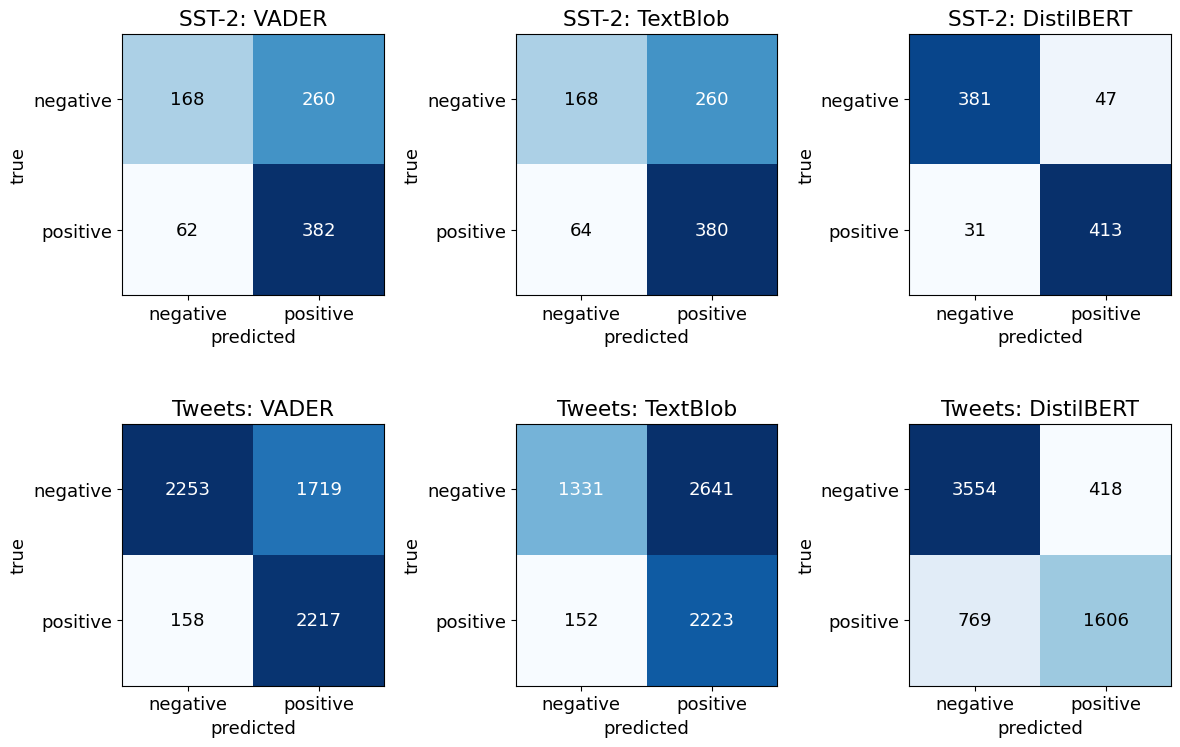

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for r, (dname, data) in enumerate(data_sets.items()):
    for c, (mname, col) in enumerate(models.items()):
        ax = axes[r, c]
        cm = confusion_matrix(data["label"], data[col])
        ax.imshow(cm, cmap="Blues")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i, j], ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2 else "black")
        ax.set_xticks([0, 1], ["negative", "positive"])
        ax.set_yticks([0, 1], ["negative", "positive"])
        ax.set_xlabel("predicted")
        ax.set_ylabel("true")
        ax.set_title(dname + ": " + mname)
plt.tight_layout()
plt.savefig("results/confusion_matrices.png", dpi=300)
plt.savefig("results/confusion_matrices.pdf")
plt.show()

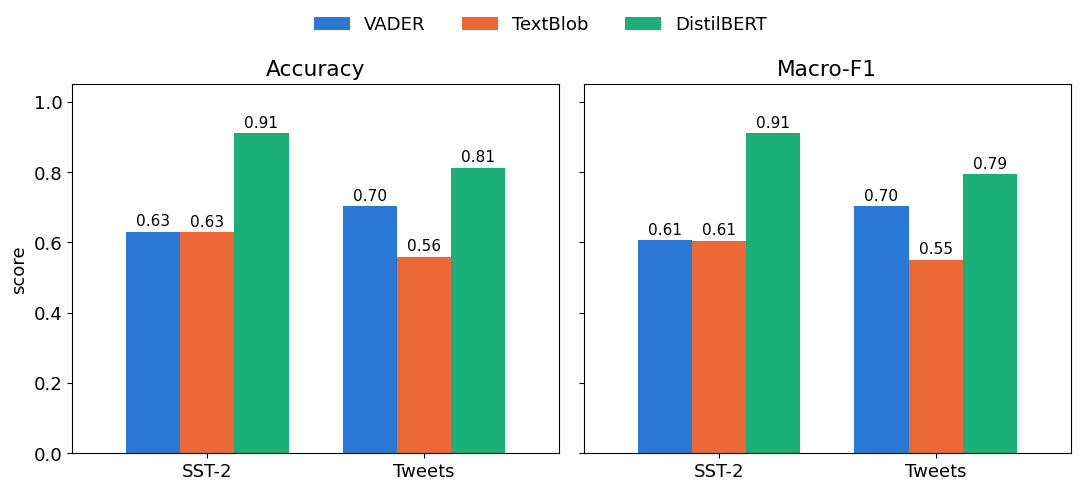

In [9]:
colors = ["#2a78d6", "#eb6834", "#1baf7a"]
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, metric in zip(axes, ["Accuracy", "Macro-F1"]):
    table = metrics.pivot(index="Dataset", columns="Model", values=metric)[list(models)]
    table.plot(kind="bar", ax=ax, color=colors, width=0.75, legend=False)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=11, padding=2)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=0)
axes[0].set_ylabel("score")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("results/metrics_bar.png", dpi=300)
plt.savefig("results/metrics_bar.pdf")
plt.show()

## Significance

Exact McNemar test for each pair of models on the same examples (Dietterich, 1998). 6 tests, so Bonferroni: significant if p < 0.05 / 6.

In [10]:
pairs = [("VADER", "TextBlob"), ("VADER", "DistilBERT"), ("TextBlob", "DistilBERT")]
n_tests = len(pairs) * len(data_sets)

rows = []
for dname, data in data_sets.items():
    for a, b in pairs:
        a_ok = data[a.lower() + "_correct"]
        b_ok = data[b.lower() + "_correct"]
        table = [[(a_ok & b_ok).sum(), (a_ok & ~b_ok).sum()],
                 [(~a_ok & b_ok).sum(), (~a_ok & ~b_ok).sum()]]
        p = mcnemar(table, exact=True).pvalue
        rows.append([dname, a + " vs " + b, table[0][1], table[1][0], p, p < 0.05 / n_tests])

sig = pd.DataFrame(rows, columns=["Dataset", "Pair", "only 1st correct", "only 2nd correct", "p-value", "significant"])
sig.to_csv("results/mcnemar.csv", index=False)
sig

,Dataset,Pair,only 1st correct,only 2nd correct,p-value,significant
0,SST-2,VADER vs TextBlob,105,103,9.447431e-01,False
1,SST-2,VADER vs DistilBERT,29,273,6.439496e-51,True
2,SST-2,TextBlob vs DistilBERT,32,278,4.150592e-50,True
3,Tweets,VADER vs TextBlob,1336,420,5.588566e-111,True
4,Tweets,VADER vs DistilBERT,813,1503,3.576343e-47,True
5,Tweets,TextBlob vs DistilBERT,783,2389,4.749310e-187,True


## Error analysis

Accuracy on examples with a negation word or a contrast word, and on examples where a lexicon model scored exactly 0. Just keyword matching, so it's a rough picture.

In [11]:
negation_words = {"not", "no", "never", "nothing", "none", "nobody", "neither", "nor", "without", "hardly",
                  "cannot", "dont", "doesnt", "didnt", "isnt", "wasnt", "cant", "wont"}
contrast_words = {"but", "however", "although", "though", "yet", "despite"}

def words(s):
    return [w.strip(".,!?;:\"'()").lower() for w in s.split()]

def has_negation(s):
    return any(w in negation_words or w.endswith("n't") or w.endswith("n’t") for w in words(s))

def has_contrast(s):
    return any(w in contrast_words for w in words(s))

rows = []
for dname, data in data_sets.items():
    neg = data["sentence"].apply(has_negation)
    con = data["sentence"].apply(has_contrast)
    subsets = {
        "all": data,
        "with negation": data[neg],
        "without negation": data[~neg],
        "with contrast word": data[con],
        "without contrast word": data[~con],
        "VADER score = 0": data[data["vader_score"] == 0],
        "TextBlob score = 0": data[data["textblob_score"] == 0],
    }
    for name, sub in subsets.items():
        rows.append([dname, name, len(sub), sub["vader_correct"].mean(),
                     sub["textblob_correct"].mean(), sub["distilbert_correct"].mean()])

subset_acc = pd.DataFrame(rows, columns=["Dataset", "subset", "n", "VADER", "TextBlob", "DistilBERT"]).round(3)
subset_acc.to_csv("results/subset_accuracy.csv", index=False)
subset_acc

,Dataset,subset,n,VADER,TextBlob,DistilBERT
0,SST-2,all,872,0.631,0.628,0.911
1,SST-2,with negation,200,0.540,0.470,0.860
2,SST-2,without negation,672,0.658,0.676,0.926
3,SST-2,with contrast word,141,0.553,0.596,0.872
4,SST-2,without contrast word,731,0.646,0.635,0.918
5,SST-2,VADER score = 0,141,0.390,0.468,0.901
6,SST-2,TextBlob score = 0,129,0.543,0.388,0.853
7,Tweets,all,6347,0.704,0.560,0.813
8,Tweets,with negation,1364,0.597,0.436,0.837
9,Tweets,without negation,4983,0.734,0.594,0.807


30 wrong predictions per model on SST-2, sampled at random (seed 42). Each one was given one error type by reading it. If more than one fits, the first in this order is used: no sentiment found (lexicon score is exactly 0, checked below), questionable gold label (the sentence clearly reads the other way), sarcasm / irony, negation (the part that carries the verdict depends on not, n't, no, never etc.), mixed sentiment (a positive and a negative part and the model goes with the wrong one), misleading sentiment word (a sentiment word that isn't the verdict, e.g. "crisis", "terribly", or "like" in "treats women like idiots"), context / world knowledge (idioms, comparisons, outside knowledge, no single word to blame), other.

The labels are in `error_sample_labels.csv`. Some are judgement calls, mostly between misleading word and context.

In [12]:
parts = []
for mname in models:
    errors = df[~df[mname.lower() + "_correct"]]
    part = errors.sample(30, random_state=42)[["idx", "sentence", "label", "vader_score", "textblob_score",
                                               "distilbert_pred", "distilbert_conf"]].copy()
    part.insert(0, "model", mname)
    parts.append(part)
err_sample = pd.concat(parts, ignore_index=True)
err_sample.to_csv("results/error_sample.csv", index=False)

In [13]:
types = ["no sentiment found (score 0)", "questionable gold label", "sarcasm / irony", "negation",
         "mixed sentiment", "misleading sentiment word", "context / world knowledge", "other"]

labels = pd.read_csv("error_sample_labels.csv")
merged = err_sample.merge(labels[["model", "idx", "error_type"]], on=["model", "idx"])
assert len(merged) == 90 and merged["error_type"].isin(types).all()
# the score-0 type has to match the actual scores
for m in ["VADER", "TextBlob"]:
    sub = merged[merged["model"] == m]
    assert ((sub["error_type"] == types[0]) == (sub[m.lower() + "_score"] == 0)).all()
assert not ((merged["model"] == "DistilBERT") & (merged["error_type"] == types[0])).any()

counts = pd.crosstab(merged["error_type"], merged["model"]).reindex(index=types, columns=list(models), fill_value=0)
counts.to_csv("results/error_types.csv")
percent = (counts / 30 * 100).round(1)
percent

model,VADER,TextBlob,DistilBERT
error_type,,,
no sentiment found (score 0),16.7,20.0,0.0
questionable gold label,0.0,3.3,10.0
sarcasm / irony,3.3,0.0,10.0
negation,10.0,26.7,20.0
mixed sentiment,6.7,6.7,33.3
misleading sentiment word,46.7,30.0,3.3
context / world knowledge,13.3,10.0,23.3
other,3.3,3.3,0.0


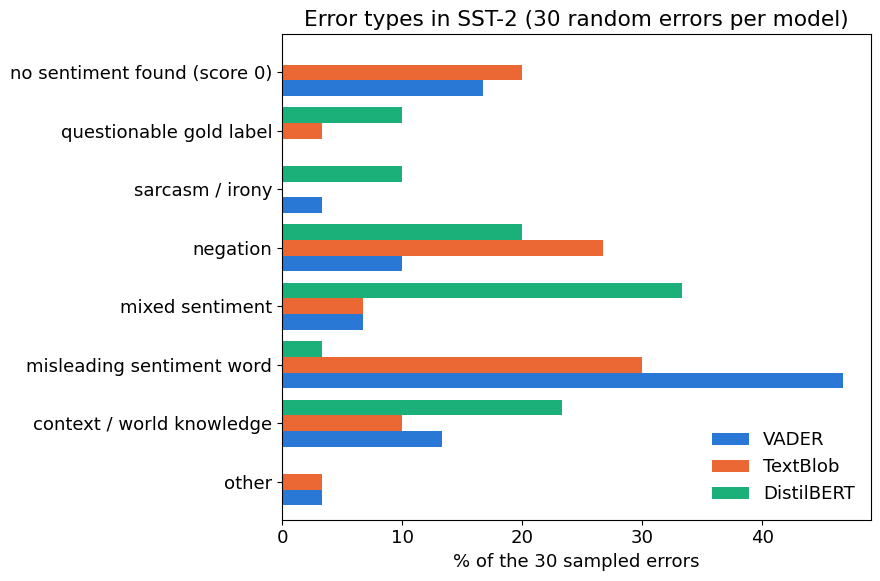

In [14]:
ax = percent.iloc[::-1].plot(kind="barh", figsize=(9, 6), color=colors, width=0.8)
ax.set_xlabel("% of the 30 sampled errors")
ax.set_ylabel("")
ax.set_title("Error types in SST-2 (30 random errors per model)")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.savefig("results/error_types.png", dpi=300)
plt.savefig("results/error_types.pdf")
plt.show()

A few examples per model, picked by hand (label 1 = positive).

In [15]:
picked = [
    (298, "VADER", "negation"),
    (154, "VADER", "misleading sentiment word"),
    (211, "VADER", "context / world knowledge"),
    (818, "VADER", "sarcasm / irony"),
    (310, "VADER", "mixed sentiment"),
    (486, "TextBlob", "negation"),
    (193, "TextBlob", "misleading sentiment word"),
    (89, "TextBlob", "mixed sentiment"),
    (709, "TextBlob", "sarcasm / irony"),
    (539, "TextBlob", "no sentiment found (score 0)"),
    (685, "DistilBERT", "negation"),
    (22, "DistilBERT", "context / world knowledge"),
    (183, "DistilBERT", "sarcasm / irony"),
    (667, "DistilBERT", "mixed sentiment"),
    (519, "DistilBERT", "questionable gold label"),
]
examples = pd.DataFrame(picked, columns=["idx", "model", "error_type"]).merge(df, on="idx")
for _, r in examples.iterrows():
    assert r[r["model"].lower() + "_pred"] != r["label"], r["idx"]  # model really got it wrong

examples = examples[["idx", "model", "error_type", "sentence", "label", "vader_pred", "textblob_pred", "distilbert_pred"]]
examples.to_csv("results/error_examples.csv", index=False)
examples

,idx,model,error_type,sentence,label,vader_pred,textblob_pred,distilbert_pred
0,298,VADER,negation,serving sara does n't serve up a whole lot of laughs .,0,1,1,0
1,154,VADER,misleading sentiment word,a solid examination of the male midlife crisis .,1,0,1,1
2,211,VADER,context / world knowledge,to say this was done better in wilder 's some like it hot is like saying the sun rises in the east .,0,1,1,0
3,818,VADER,sarcasm / irony,the only excitement comes when the credits finally roll and you get to leave the theater .,0,1,1,0
4,310,VADER,mixed sentiment,"if you can stomach the rough content , it 's worth checking out for the performances alone .",1,0,1,1
5,486,TextBlob,negation,the script is n't very good ; not even someone as gifted as hoffman ( the actor ) can make it work .,0,0,1,0
6,193,TextBlob,misleading sentiment word,"morton uses her face and her body language to bring us morvern 's soul , even though the character is almost completely deadpan .",1,1,0,1
7,89,TextBlob,mixed sentiment,"we know the plot 's a little crazy , but it held my interest from start to finish .",1,1,0,1
8,709,TextBlob,sarcasm / irony,i thought my own watch had stopped keeping time as i slogged my way through clockstoppers .,0,0,1,0
9,539,TextBlob,no sentiment found (score 0),do not see this film .,0,1,1,0


## Hand-written sentences

Not from either dataset (no gold label), just to see how the models react to "but" and to the SST-2 style "n't".

In [16]:
tests = [
    "The plot was predictable, but the acting was outstanding.",
    "The acting was outstanding, but the plot was predictable.",
    "the movie is not good .",
    "the movie is n't good .",
    "the movie isn't good.",
    "not bad at all .",
]
rows = []
for s in tests:
    out = clf(s)[0]
    rows.append([s, vader.polarity_scores(s)["compound"], TextBlob(s).sentiment.polarity, out["label"], round(out["score"], 3)])
pd.DataFrame(rows, columns=["sentence", "VADER", "TextBlob", "DistilBERT", "DistilBERT conf"])

,sentence,VADER,TextBlob,DistilBERT,DistilBERT conf
0,"The plot was predictable, but the acting was outstanding.",0.7579,0.10,POSITIVE,1.000
1,"The acting was outstanding, but the plot was predictable.",0.3612,0.10,NEGATIVE,0.999
2,the movie is not good .,-0.3412,-0.35,NEGATIVE,1.000
3,the movie is n't good .,-0.3412,0.70,NEGATIVE,1.000
4,the movie isn't good.,-0.3412,0.70,NEGATIVE,1.000
5,not bad at all .,0.4310,0.35,POSITIVE,0.999
